<a href="https://colab.research.google.com/github/martingomezpizarro/Estrategias/blob/main/Estrategia_Opciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import json
import numpy as np
import pandas as pd
from google.colab import files
from pandas import Series, DataFrame
import io
import csv
import openpyxl
import xlrd
from openpyxl import load_workbook
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import yfinance as yf
import itertools
import seaborn as sns

In [ ]:
fecha_inicio = input("Ingrese la fecha de inicio del periodo en el que quiere realizar la prueba (YYYY-MM-DD): ")
fecha_final = input("Ingrese la fecha final del periodo en el que quiere realizar la prueba (YYYY-MM-DD): ")

# Convertir las cadenas de entrada a objetos datetime
fecha_inicio = datetime.strptime(fecha_inicio, '%Y-%m-%d')
fecha_final = datetime.strptime(fecha_final, '%Y-%m-%d')

# Establecer el primer día del mes
fecha_inicio_m = datetime(fecha_inicio.year, fecha_inicio.month, 1)
fecha_final_m = datetime(fecha_final.year, fecha_final.month, 1)

# Convertir a Timestamp de pandas
fecha_inicio = pd.Timestamp(fecha_inicio)
fecha_final = pd.Timestamp(fecha_final)
fecha_inicio_m = pd.Timestamp(fecha_inicio_m)
fecha_final_m = pd.Timestamp(fecha_final_m)
# Imprimir en el formato deseado
print(f"Fecha inicio: {fecha_inicio}")
print(f"Fecha final: {fecha_final}")

data = yf.download('GGAL.BA', start= fecha_inicio, end= fecha_final+ relativedelta(days=1), interval="1d")
dias = int(input("Ingrese la cantidad de dias de cotización: "))
wwper = 0.275
# wwper = float(input('Ingrese el % que considera ganaria más del 100%:'))
wper = 0.1375
# wper = float(input('Ingrese el % que considera que comenzaria a tener una posición ganadora:'))
llper = 0.07
# llper = float(input('Ingrese el % que considera perderia más del 50%:'))
sunkper = 0.01
datasub = data.iloc[:-dias,0]
dataplus = data.iloc[dias:,0]
var_por = (dataplus.values-datasub.values)/datasub.values
w = var_por[abs(var_por)>(wper)]
l = var_por[abs(var_por)<(wper)]
ww = var_por[abs(var_por)>(wwper)]
ll = var_por[abs(var_por)<(llper)]
mean = var_por[(abs(var_por) < wwper) & (abs(var_por) > llper)]
sunk = var_por[abs(var_por)<(sunkper)]
cantidades = [len(ww),len(w),len(l),len(ll),len(sunk),len(mean)]

Ingrese la fecha de inicio del periodo en el que quiere realizar la prueba (YYYY-MM-DD): 2023-11-20
Ingrese la fecha final del periodo en el que quiere realizar la prueba (YYYY-MM-DD): 2025-11-07
Fecha inicio: 2023-11-20 00:00:00
Fecha final: 2025-11-07 00:00:00


/tmp/ipython-input-857324168.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GGAL.BA', start= fecha_inicio, end= fecha_final+ relativedelta(days=1), interval="1d")
[*********************100%***********************]  1 of 1 completed


Ingrese la cantidad de dias de cotización: 29


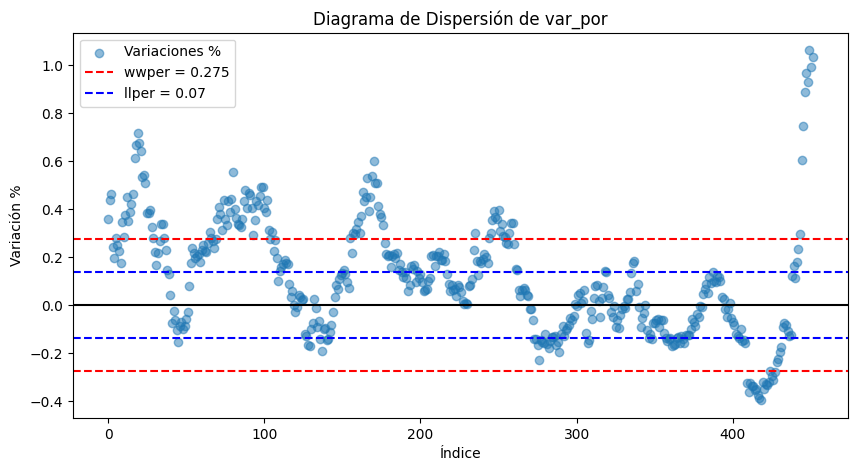

/tmp/ipython-input-987223939.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categorias, y=cantidades, palette="coolwarm")


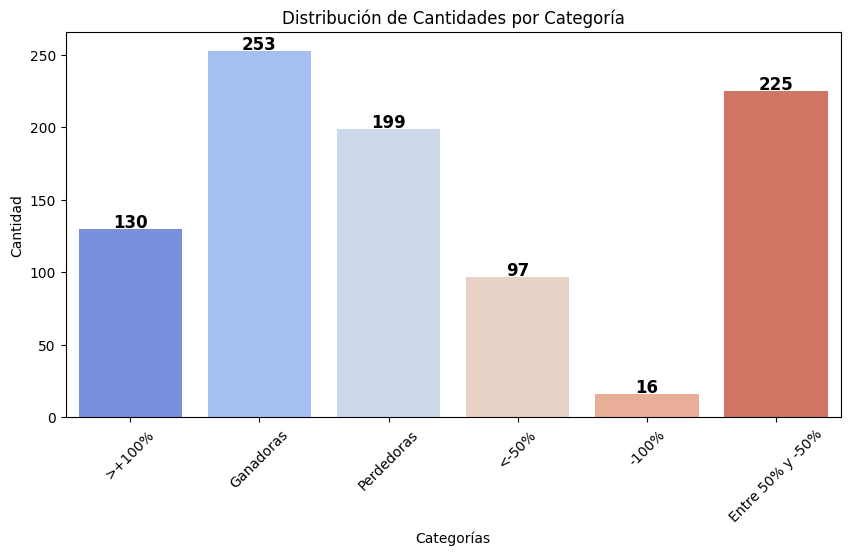

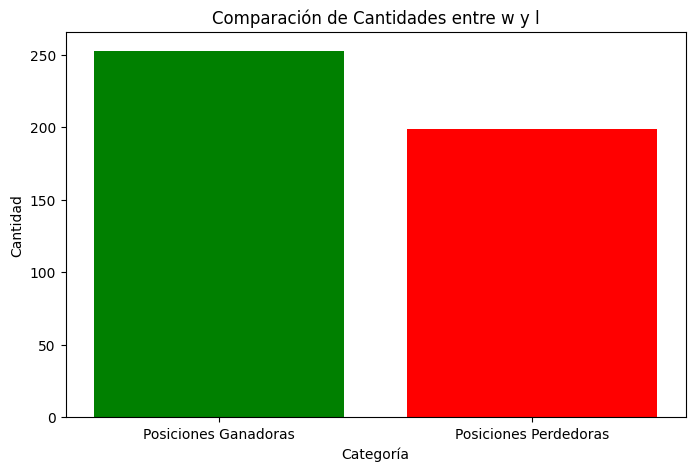

In [ ]:
categorias = ['>+100%', 'Ganadoras', 'Perdedoras', '<-50%', '-100%', 'Entre 50% y -50%']

plt.figure(figsize=(10, 5))
plt.scatter(range(len(var_por)), var_por, alpha=0.5, label="Variaciones %")
plt.axhline(y=wwper, color='r', linestyle='--', label=f'wwper = {wwper}')
plt.axhline(y=-wwper, color='r', linestyle='--')
plt.axhline(y=wper, color='b', linestyle='--', label=f'llper = {llper}')
plt.axhline(y=-wper, color='b', linestyle='--')
plt.axhline(y=0, color='black', linestyle='-')

plt.xlabel("Índice")
plt.ylabel("Variación %")
plt.title("Diagrama de Dispersión de var_por")
plt.legend()
plt.show()

# ---- Gráfico 2: Histograma de Cantidades por Categoría ----
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=categorias, y=cantidades, palette="coolwarm")

# Agregar valores en las barras
for i, cantidad in enumerate(cantidades):
    ax.text(i, cantidad + 1, str(cantidad), ha='center', fontsize=12, fontweight='bold')

plt.xlabel("Categorías")
plt.ylabel("Cantidad")
plt.title("Distribución de Cantidades por Categoría")
plt.xticks(rotation=45)
plt.show()

# ---- Gráfico 3: Comparación de w y l ----
plt.figure(figsize=(8, 5))
plt.bar(["Posiciones Ganadoras", "Posiciones Perdedoras"], [len(w), len(l)], color=['green', 'red'])
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.title("Comparación de Cantidades entre w y l")
plt.show()

In [ ]:
import requests
import json

# Tu API Key de BYMA
api_key = "TU_API_KEY"

# Endpoint de la API de Market Data
# url = "https://api.byma.com.ar/v1/marketdata/tickers"
url = "https://apigw.byma.com.ar/snapshot/v1/equity"

# Parámetros para consultar solo OPCIONES
params = {
    "Group": "ACCIONES",          # Opciones financieras
    "subGroup": "LIDER",            # En pesos
    "OperativeForm": "CONTADO",    # Solo precio de cierre
    "SettlPeriod": "0001"
}

# Encabezados con autenticación
headers = {
    "accept": "application/json",
    "x-api-key": api_key
}

# Hacer la solicitud
response = requests.get(url, params=params, headers=headers)

# Mostrar resultados
if response.status_code == 200:
    data = response.json()
    print("Precio de cierre:", data)
else:
    print("Error en la solicitud:", response.status_code)
    print(response.text)

Error en la solicitud: 401
{"status":401,"description":"Authentication credentials were not provided.","error":"NotAuthenticated","type":"api-error"}


In [ ]:
from openBYMAdata() import *
PyOBD=openBYMAdata()

ModuleNotFoundError: No module named 'openBYMAdata'